# Deadlock Match Data — Exploratory Analysis

Working with `collected_matches_sample.jsonl` (1000 matches) plus lookup tables for hero/item names.

In [194]:
import json
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 40)

## Load lookup tables

In [195]:
items_lookup = pd.read_parquet('data/public_items.parquet')
heroes_lookup = pd.read_parquet('data/public_heroes.parquet')

# Decode bytes columns if needed
for col in items_lookup.select_dtypes(include='object').columns:
    items_lookup[col] = items_lookup[col].apply(
        lambda x: x.decode() if isinstance(x, bytes) else x
    )

print('items_lookup shape:', items_lookup.shape)
display(items_lookup.head(5))

print('heroes_lookup shape:', heroes_lookup.shape)
display(heroes_lookup.head(5))

items_lookup shape: (455, 6)


/tmp/ipykernel_5298/2239931464.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in items_lookup.select_dtypes(include='object').columns:


,id,name,tier,type,slot_type,cost
0,6698938,tokamak_heat_sinks,NaN,ability,NaN,NaN
1,7409189,Improved Spirit,2.0,upgrade,spirit,1600.0
2,11154161,Hex-Lined Snap Trap,NaN,ability,NaN,NaN
3,12456023,Spectral Assistant,NaN,ability,NaN,NaN
4,18921423,Frost Grenade,NaN,ability,NaN,NaN


heroes_lookup shape: (38, 2)


,id,name
0,1,Infernus
1,2,Seven
2,3,Vindicta
3,4,Lady Geist
4,6,Abrams


In [196]:
# Only real purchasable items (type == 'upgrade'); exclude ability entries
upgrade_items = items_lookup[items_lookup['type'] == 'upgrade'].copy()
print(f'{len(upgrade_items)} purchasable upgrade items')
display(upgrade_items.head(10))

171 purchasable upgrade items


,id,name,tier,type,slot_type,cost
1,7409189,Improved Spirit,2.0,upgrade,spirit,1600.0
6,26002154,Melee Charge,2.0,upgrade,weapon,1600.0
8,64550694,Runed Gauntlets,5.0,upgrade,weapon,9999.0
9,84321454,Quicksilver Reload,2.0,upgrade,spirit,1600.0
10,98582110,Stalker,2.0,upgrade,weapon,1600.0
14,112198670,Spirit Shielding,2.0,upgrade,vitality,1600.0
23,230297145,Eternal Gift,5.0,upgrade,vitality,9999.0
26,334300056,Stamina Mastery,3.0,upgrade,vitality,3200.0
27,339443430,Frenzy,4.0,upgrade,weapon,6400.0
28,343572757,Spirit Burn,4.0,upgrade,spirit,6400.0


In [197]:
# Build fast id->name dicts
item_id_to_name = items_lookup.set_index('id')['name'].to_dict()
hero_id_to_name = heroes_lookup.set_index('id')['name'].to_dict()
upgrade_item_ids = set(upgrade_items['id'])

## Load match data

In [198]:
with open('data/collected_matches_sample.jsonl') as f:
    raw_matches = [json.loads(line) for line in f]

print(f'Loaded {len(raw_matches)} matches')
print('Top-level keys:', list(raw_matches[0].keys()))

Loaded 1000 matches
Top-level keys: ['average_badge_team0', 'average_badge_team1', 'banned_hero_ids', 'duration_s', 'game_mode', 'match_id', 'match_mode', 'match_outcome', 'not_scored', 'players', 'start_time', 'winning_team']


## Flatten to player-level DataFrame

One row per (match, player). Hero presence per team can be queried directly from this.

In [199]:
player_rows = []
for match in raw_matches:
    match_id     = match['match_id']
    winning_team = match['winning_team']
    duration_s   = match['duration_s']
    start_time   = match['start_time']

    for p in match['players']:
        player_rows.append({
            'match_id':     match_id,
            'start_time':   start_time,
            'duration_s':   duration_s,
            'winning_team': winning_team,
            'team':         p['team'],
            'player_slot':  p['player_slot'],
            'hero_id':      p['hero_id'],
            'kills':        p['kills'],
            'deaths':       p['deaths'],
            'assists':      p['assists'],
            'net_worth':    p['net_worth'],
            'player_level': p['player_level'],
            'last_hits':    p['last_hits'],
        })

players_df = pd.DataFrame(player_rows)
players_df['won'] = players_df['team'] == players_df['winning_team']
players_df['hero_name'] = players_df['hero_id'].map(hero_id_to_name)
players_df['start_time'] = pd.to_datetime(players_df['start_time'])

print('players_df shape:', players_df.shape)
display(players_df.head(6))

players_df shape: (12000, 15)


,match_id,start_time,duration_s,winning_team,team,player_slot,hero_id,kills,deaths,assists,net_worth,player_level,last_hits,won,hero_name
0,72213176,2026-04-01 10:00:00,2722,Team0,Team1,12,80,3,9,13,45720,34,114,False,Silver
1,72213176,2026-04-01 10:00:00,2722,Team0,Team1,10,60,19,4,9,60421,36,192,False,Sinclair
2,72213176,2026-04-01 10:00:00,2722,Team0,Team0,3,63,20,9,20,56691,36,199,True,Mina
3,72213176,2026-04-01 10:00:00,2722,Team0,Team0,5,81,1,9,17,46463,34,176,True,Celeste
4,72213176,2026-04-01 10:00:00,2722,Team0,Team0,6,6,15,4,21,62310,36,156,True,Abrams
5,72213176,2026-04-01 10:00:00,2722,Team0,Team0,4,79,3,14,27,48788,35,131,True,Rem


## Flatten to item-level DataFrame

One row per (match, player, item purchase event).

Key columns:
- `sold_time_s == 0` → **held at game end** (core build item)
- `sold_time_s > 0` → **bought then sold** (situational/counter item, e.g. Curse, Silence Glyph)

In [200]:
item_rows = []
for match in raw_matches:
    match_id     = match['match_id']
    winning_team = match['winning_team']

    for p in match['players']:
        team    = p['team']
        hero_id = p['hero_id']
        won     = (team == winning_team)

        for item in p['items']:
            # item_id in JSONL may exceed int32; cast to uint32 to match parquet
            raw_id  = item['item_id']
            item_id = np.uint32(raw_id)

            item_rows.append({
                'match_id':    match_id,
                'team':        team,
                'hero_id':     hero_id,
                'won':         won,
                'item_id':     item_id,
                'game_time_s': item['game_time_s'],
                'sold_time_s': item['sold_time_s'],
            })

items_df = pd.DataFrame(item_rows)

# Distinguish held vs sold
items_df['held']       = items_df['sold_time_s'] == 0
items_df['was_sold']   = items_df['sold_time_s'] > 0

# Name lookups
items_df['item_name']  = items_df['item_id'].map(item_id_to_name)
items_df['hero_name']  = items_df['hero_id'].map(hero_id_to_name)

# Flag whether the item is a purchasable upgrade (not an ability)
items_df['is_upgrade'] = items_df['item_id'].isin(upgrade_item_ids)

print('items_df shape:', items_df.shape)
display(items_df.head(8))

items_df shape: (373384, 12)


,match_id,team,hero_id,won,item_id,game_time_s,sold_time_s,held,was_sold,item_name,hero_name,is_upgrade
0,72213176,Team1,80,False,1385849824,14,0,True,False,Slam Fire,Silver,False
1,72213176,Team1,80,False,3862866912,68,2036,False,True,Restorative Shot,Silver,True
2,72213176,Team1,80,False,1385849824,81,0,True,False,Slam Fire,Silver,False
3,72213176,Team1,80,False,3983754897,128,0,True,False,Entangling Bola,Silver,False
4,72213176,Team1,80,False,1437614329,176,2513,False,True,Melee Lifesteal,Silver,True
5,72213176,Team1,80,False,2717130900,220,0,True,False,Boot Kick,Silver,False
6,72213176,Team1,80,False,3633614685,225,943,False,True,Extra Health,Silver,True
7,72213176,Team1,80,False,2717130900,244,0,True,False,Boot Kick,Silver,False


In [201]:
# How many item IDs matched the lookup?
total     = len(items_df)
matched   = items_df['item_name'].notna().sum()
upgrades  = items_df['is_upgrade'].sum()
print(f'Total item purchase events : {total}')
print(f'Matched to item name       : {matched} ({matched/total:.1%})')
print(f'Matched as upgrade items   : {upgrades} ({upgrades/total:.1%})')
print(f'held (not sold)            : {items_df["held"].sum()}')
print(f'sold during match          : {items_df["was_sold"].sum()}')

Total item purchase events : 373384
Matched to item name       : 373384 (100.0%)
Matched as upgrade items   : 201331 (53.9%)
held (not sold)            : 299789
sold during match          : 73595


## Hero presence per team

Given a match, which heroes were on each team?

In [202]:
def heroes_in_match(match_id: int) -> pd.DataFrame:
    """Return hero lineup per team for a single match."""
    mask = players_df['match_id'] == match_id
    return (
        players_df[mask][['team', 'hero_name', 'won']]
        .sort_values(['team', 'hero_name'])
        .reset_index(drop=True)
    )

example_match_id = players_df['match_id'].iloc[0]
display(heroes_in_match(example_match_id))

,team,hero_name,won
0,Team0,Abrams,True
1,Team0,Celeste,True
2,Team0,Haze,True
3,Team0,Lash,True
4,Team0,Mina,True
5,Team0,Rem,True
6,Team1,Billy,False
7,Team1,Graves,False
8,Team1,Silver,False
9,Team1,Sinclair,False


In [203]:
# Binary hero presence matrix: one row per match+team, one column per hero
# Useful for modeling — heroes present on that team get a 1
hero_presence = (
    players_df
    .assign(present=1)
    .pivot_table(
        index=['match_id', 'team', 'won'],
        columns='hero_name',
        values='present',
        aggfunc='max',
        fill_value=0,
    )
)
hero_presence.columns.name = None
hero_presence = hero_presence.reset_index()
print('hero_presence shape:', hero_presence.shape)
display(hero_presence.head(4))

hero_presence shape: (2000, 41)


,match_id,team,won,Abrams,Apollo,Bebop,Billy,Calico,Celeste,Drifter,Dynamo,Graves,Grey Talon,Haze,Holliday,Infernus,Ivy,Kelvin,Lady Geist,Lash,McGinnis,Mina,Mirage,Mo & Krill,Paige,Paradox,Pocket,Rem,Seven,Shiv,Silver,Sinclair,The Doorman,Venator,Victor,Vindicta,Viscous,Vyper,Warden,Wraith,Yamato
0,72213176,Team0,True,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,72213176,Team1,False,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,1,0,0,0,0,0
2,72213184,Team0,False,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
3,72213184,Team1,True,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0


## Item presence per team

Separate views for **held items** (final build) vs **sold items** (situational use).

In [204]:
def items_in_match(match_id: int, held_only: bool = True) -> pd.DataFrame:
    """Items present on each team in a match.
    
    held_only=True  → items held at end of game (core build)
    held_only=False → all items including those bought and sold
    """
    mask = (items_df['match_id'] == match_id) & items_df['is_upgrade']
    if held_only:
        mask &= items_df['held']
    return (
        items_df[mask][['team', 'hero_name', 'item_name', 'held', 'was_sold', 'game_time_s', 'sold_time_s']]
        .sort_values(['team', 'hero_name', 'game_time_s'])
        .reset_index(drop=True)
    )

print('--- Core build items ---')
display(items_in_match(example_match_id, held_only=True).head(10))

print('--- Items bought and then sold ---')
sold = items_df[
    (items_df['match_id'] == example_match_id) &
    items_df['is_upgrade'] &
    items_df['was_sold']
][['team', 'hero_name', 'item_name', 'game_time_s', 'sold_time_s']]
display(sold)

--- Core build items ---


,team,hero_name,item_name,held,was_sold,game_time_s,sold_time_s
0,Team0,Abrams,Melee Charge,True,False,962,0
1,Team0,Abrams,Point Blank,True,False,1105,0
2,Team0,Abrams,Hunter's Aura,True,False,1281,0
3,Team0,Abrams,Lifestrike,True,False,1362,0
4,Team0,Abrams,Superior Duration,True,False,1492,0
5,Team0,Abrams,Phantom Strike,True,False,1638,0
6,Team0,Abrams,Hollow Point,True,False,1770,0
7,Team0,Abrams,Spirit Snatch,True,False,1877,0
8,Team0,Abrams,Torment Pulse,True,False,1898,0
9,Team0,Abrams,Bullet Resilience,True,False,2163,0


--- Items bought and then sold ---


,team,hero_name,item_name,game_time_s,sold_time_s
1,Team1,Silver,Restorative Shot,68,2036
4,Team1,Silver,Melee Lifesteal,176,2513
6,Team1,Silver,Extra Health,225,943
8,Team1,Silver,Close Quarters,335,1506
10,Team1,Silver,High-Velocity Rounds,434,657
...,...,...,...,...,...
388,Team1,Billy,Healing Rite,409,2648
389,Team1,Billy,Extra Regen,449,2506
390,Team1,Billy,Close Quarters,531,986
391,Team1,Billy,Extra Health,630,2710


In [205]:
# Binary item presence matrix (held items only, upgrade items only)
# Aggregated per (match, team) — 1 if ANY player on the team held that item
held_upgrades = items_df[items_df['is_upgrade'] & items_df['held']]

item_presence = (
    held_upgrades
    .assign(present=1)
    .pivot_table(
        index=['match_id', 'team'],
        columns='item_name',
        values='present',
        aggfunc='max',
        fill_value=0,
    )
)
item_presence.columns.name = None
item_presence = item_presence.reset_index()

# Attach win label
team_outcomes = (
    players_df[['match_id', 'team', 'won']]
    .drop_duplicates()
)
item_presence = item_presence.merge(team_outcomes, on=['match_id', 'team'])

print('item_presence shape:', item_presence.shape)
display(item_presence.iloc[:3, :8])

item_presence shape: (2000, 157)


,match_id,team,Active Reload,Alchemical Fire,Arcane Surge,Arctic Blast,Armor Piercing Rounds,Ballistic Enchantment
0,72213176,Team0,1,0,0,1,1,0
1,72213176,Team1,1,0,0,0,0,0
2,72213184,Team0,1,1,0,1,0,0


## Quick EDA

In [206]:
# Most picked heroes overall
hero_picks = (
    players_df['hero_name']
    .value_counts()
    .rename('picks')
    .to_frame()
)
hero_picks['pick_rate'] = hero_picks['picks'] / len(raw_matches)
display(hero_picks.head(15))

,picks,pick_rate
hero_name,,
Rem,555,0.555
Haze,555,0.555
Graves,550,0.550
Infernus,494,0.494
Mina,467,0.467
Venator,442,0.442
Dynamo,428,0.428
Drifter,424,0.424
Lash,399,0.399


In [207]:
# Hero win rates (min 20 games)
hero_wr = (
    players_df
    .groupby('hero_name')
    .agg(games=('won', 'count'), wins=('won', 'sum'))
)
hero_wr['win_rate'] = hero_wr['wins'] / hero_wr['games']
display(hero_wr[hero_wr['games'] >= 20].sort_values('win_rate', ascending=False).head(15))

,games,wins,win_rate
hero_name,,,
Seven,396,225,0.568182
Infernus,494,279,0.564777
Dynamo,428,239,0.558411
Haze,555,305,0.549550
McGinnis,197,107,0.543147
Drifter,424,229,0.540094
Calico,202,107,0.529703
Lady Geist,295,156,0.528814
The Doorman,381,201,0.527559


In [208]:
# Most common held items (upgrade only)
held_upgrade_items = items_df[items_df['is_upgrade'] & items_df['held']]
item_freq = (
    held_upgrade_items['item_name']
    .value_counts()
    .rename('times_held')
    .to_frame()
)
# Rate: out of 1000 matches × 12 players
item_freq['hold_rate'] = item_freq['times_held'] / (len(raw_matches) * 12)
display(item_freq.head(20))

,times_held,hold_rate
item_name,,
Boundless Spirit,4744,0.395333
Rapid Recharge,3827,0.318917
Greater Expansion,3764,0.313667
Enduring Speed,3320,0.276667
Tankbuster,3173,0.264417
Superior Duration,3132,0.261000
Transcendent Cooldown,3113,0.259417
Stamina Mastery,3017,0.251417
Spirit Resilience,2767,0.230583


In [209]:
# Most common SOLD (situational) items
sold_items = items_df[items_df['is_upgrade'] & items_df['was_sold']]
display(
    sold_items['item_name']
    .value_counts()
    .rename('times_sold')
    .head(20)
)

item_name
Extra Spirit            6352
Improved Spirit         4367
Compress Cooldown       4170
Extra Stamina           3913
Extra Charge            3742
Mystic Expansion        3442
Sprint Boots            3278
Mystic Burst            3256
Superior Cooldown       2747
Extra Regen             2338
Duration Extender       2332
Rapid Rounds            2090
Monster Rounds          1897
Bullet Lifesteal        1760
Spirit Lifesteal        1653
Close Quarters          1649
Healing Rite            1639
Mystic Vulnerability    1605
Extra Health            1339
Extended Magazine       1279
Name: times_sold, dtype: int64

In [210]:
# Win rate by item presence (held, upgrade items, min 50 matches with item)
item_cols = [c for c in item_presence.columns if c not in ('match_id', 'team', 'won')]

item_wr_rows = []
for col in item_cols:
    grp = item_presence.groupby(col)['won']
    counts = grp.count()
    if counts.get(1, 0) < 50:
        continue
    item_wr_rows.append({
        'item':      col,
        'n_with':    counts.get(1, 0),
        'n_without': counts.get(0, 0),
        'wr_with':   grp.mean().get(1, float('nan')),
        'wr_without':grp.mean().get(0, float('nan')),
    })

item_wr_df = pd.DataFrame(item_wr_rows)
item_wr_df['wr_delta'] = item_wr_df['wr_with'] - item_wr_df['wr_without']
display(item_wr_df.sort_values('wr_delta', ascending=False).head(20))

,item,n_with,n_without,wr_with,wr_without,wr_delta
35,Escalating Exposure,1279,721,0.562158,0.389736,0.172421
75,Lucky Shot,434,1566,0.603687,0.471264,0.132422
102,Restorative Locket,119,1881,0.621849,0.492291,0.129557
109,Silencer,479,1521,0.597077,0.469428,0.127649
115,Spirit Burn,1067,933,0.554827,0.437299,0.117528
106,Scourge,138,1862,0.608696,0.491944,0.116752
72,Leech,1182,818,0.547377,0.431540,0.115837
48,Frenzy,194,1806,0.603093,0.488926,0.114167
130,Superior Duration,1654,346,0.519347,0.407514,0.111833
124,Spiritual Overflow,386,1614,0.582902,0.480173,0.102728


## Modeling DataFrame

Unit of analysis: one row per (match, team).

For each row:
- `won` — did this team win?
- `skill_tier` — `'low'` (avg badge < 100) or `'high'` (avg badge ≥ 100)
- `enemy_has_<Hero>` — bool, target hero is on the **opposing** team
- `bought_<Item>` — bool, any player on **this** team bought the item (held or sold)
- `held_<Item>` — bool, any player on **this** team held the item at game end

Counter-item pairs under study (from proposal):
| Item | Target Hero |
|---|---|
| Knockdown | Dynamo |
| Disarming Hex | Haze |
| Slowing Hex | Mina |
| Dispel Magic | Infernus |

In [211]:
COUNTER_PAIRS = {
    'Knockdown':     ('Dynamo',   np.uint32(1254091416)),
    'Disarming Hex': ('Haze',     np.uint32(2061878743)),
    'Slowing Hex':   ('Mina',     np.uint32(1813726886)),
    'Dispel Magic':  ('Infernus', np.uint32(3731635960)),
}

# --- per (match, team): item purchase flags ---
target_ids = {iid for _, iid in COUNTER_PAIRS.values()}
target_df  = items_df[items_df['item_id'].isin(target_ids)]

# any player on this team held the item at game end
held_flags = (
    target_df[target_df['held']]
    .groupby(['match_id', 'team', 'item_id'])
    .size().gt(0).astype(int)
    .rename('flag')
    .reset_index()
)

# any player on this team bought the item at any point (held OR sold)
bought_flags = (
    target_df
    .groupby(['match_id', 'team', 'item_id'])
    .size().gt(0).astype(int)
    .rename('flag')
    .reset_index()
)

def flags_to_wide(flags_df, prefix):
    """Pivot item flags into one boolean column per item name."""
    id_to_item = {iid: name for name, (_, iid) in COUNTER_PAIRS.items()}
    flags_df = flags_df.copy()
    flags_df['col'] = prefix + flags_df['item_id'].map(id_to_item)
    return flags_df.pivot_table(
        index=['match_id', 'team'], columns='col', values='flag',
        aggfunc='max', fill_value=0
    ).reset_index()

held_wide  = flags_to_wide(held_flags,  'held_')
bought_wide = flags_to_wide(bought_flags, 'bought_')

# --- per (match, team): enemy hero presence ---
# opponent team for each (match, team) row
other_team = {'Team0': 'Team1', 'Team1': 'Team0'}

target_heroes = {hero for hero, _ in COUNTER_PAIRS.values()}
hero_flags = (
    players_df[players_df['hero_name'].isin(target_heroes)]
    [['match_id', 'team', 'hero_name']]
    .assign(present=1)
    .pivot_table(index=['match_id', 'team'], columns='hero_name',
                 values='present', aggfunc='max', fill_value=0)
    .reset_index()
)
# rename so columns reflect the ENEMY having that hero
hero_flags.columns = (
    ['match_id', 'team'] +
    ['enemy_has_' + c for c in hero_flags.columns[2:]]
)
# shift hero flags to the *opposing* team's row
hero_flags['team'] = hero_flags['team'].map(other_team)

# --- skill tier from match-level badge averages ---
match_meta = pd.DataFrame([{
    'match_id':    m['match_id'],
    'badge_team0': m['average_badge_team0'],
    'badge_team1': m['average_badge_team1'],
    'duration_s':  m['duration_s'],
    'start_time':  m['start_time'],
} for m in raw_matches])

# melt to (match, team) level
badge_long = pd.melt(
    match_meta,
    id_vars=['match_id', 'duration_s', 'start_time'],
    value_vars=['badge_team0', 'badge_team1'],
    var_name='team_badge', value_name='avg_badge'
)
badge_long['team'] = badge_long['team_badge'].map(
    {'badge_team0': 'Team0', 'badge_team1': 'Team1'}
)
badge_long['skill_tier'] = np.where(badge_long['avg_badge'] >= 100, 'high', 'low')
badge_long = badge_long[['match_id', 'team', 'avg_badge', 'skill_tier', 'duration_s', 'start_time']]

# --- team outcomes ---
outcomes = (
    players_df[['match_id', 'team', 'won']]
    .drop_duplicates()
)

# --- assemble ---
model_df = (
    outcomes
    .merge(badge_long,  on=['match_id', 'team'])
    .merge(held_wide,   on=['match_id', 'team'], how='left')
    .merge(bought_wide, on=['match_id', 'team'], how='left')
    .merge(hero_flags,  on=['match_id', 'team'], how='left')
    .fillna(0)
)

# ensure bool columns are int (0/1) for stats tests
flag_cols = [c for c in model_df.columns if c.startswith(('held_', 'bought_', 'enemy_has_'))]
model_df[flag_cols] = model_df[flag_cols].astype(int)
model_df['won'] = model_df['won'].astype(int)

print('model_df shape:', model_df.shape)
display(model_df.head(6))

model_df shape: (2000, 19)


,match_id,team,won,avg_badge,skill_tier,duration_s,start_time,held_Disarming Hex,held_Dispel Magic,held_Knockdown,held_Slowing Hex,bought_Disarming Hex,bought_Dispel Magic,bought_Knockdown,bought_Slowing Hex,enemy_has_Dynamo,enemy_has_Haze,enemy_has_Infernus,enemy_has_Mina
0,72213176,Team1,0,12,low,2722,2026-04-01 10:00:00,0,0,0,0,0,0,0,0,0,1,0,1
1,72213176,Team0,1,12,low,2722,2026-04-01 10:00:00,1,1,1,0,1,1,1,0,0,0,0,0
2,72213184,Team0,0,22,low,2195,2026-04-01 10:00:04,0,0,0,0,0,0,0,0,0,0,1,0
3,72213184,Team1,1,23,low,2195,2026-04-01 10:00:04,0,0,0,0,0,0,0,0,0,0,0,1
4,72213187,Team0,1,54,low,1915,2026-04-01 10:00:04,0,0,0,0,0,0,0,0,0,0,0,0
5,72213187,Team1,0,54,low,1915,2026-04-01 10:00:04,1,1,0,0,1,1,0,1,0,0,1,0


In [212]:
# Sanity check: purchase rates and enemy presence rates per pair, split by skill tier
rows = []
for item, (hero, _) in COUNTER_PAIRS.items():
    enemy_col  = f'enemy_has_{hero}'
    bought_col = f'bought_{item}'
    held_col   = f'held_{item}'
    for tier, grp in model_df.groupby('skill_tier'):
        n             = len(grp)
        enemy_present = grp[enemy_col].sum()
        with_enemy    = grp[grp[enemy_col] == 1]
        without_enemy = grp[grp[enemy_col] == 0]
        rows.append({
            'item':              item,
            'target_hero':       hero,
            'skill_tier':        tier,
            'n_teams':           n,
            'enemy_present':     enemy_present,
            'bought_w_enemy':    with_enemy[bought_col].mean().round(3),
            'bought_wo_enemy':   without_enemy[bought_col].mean().round(3),
            'held_w_enemy':      with_enemy[held_col].mean().round(3) if held_col in grp else None,
            'held_wo_enemy':     without_enemy[held_col].mean().round(3) if held_col in grp else None,
        })

sanity_df = pd.DataFrame(rows)
display(sanity_df)

,item,target_hero,skill_tier,n_teams,enemy_present,bought_w_enemy,bought_wo_enemy,held_w_enemy,held_wo_enemy
0,Knockdown,Dynamo,high,213,51,0.275,0.278,0.255,0.272
1,Knockdown,Dynamo,low,1787,377,0.337,0.317,0.326,0.306
2,Disarming Hex,Haze,high,213,56,0.143,0.102,0.143,0.096
3,Disarming Hex,Haze,low,1787,499,0.170,0.128,0.158,0.122
4,Slowing Hex,Mina,high,213,32,0.719,0.558,0.594,0.392
5,Slowing Hex,Mina,low,1787,435,0.485,0.415,0.308,0.267
6,Dispel Magic,Infernus,high,213,59,0.831,0.701,0.831,0.688
7,Dispel Magic,Infernus,low,1787,435,0.579,0.426,0.552,0.411


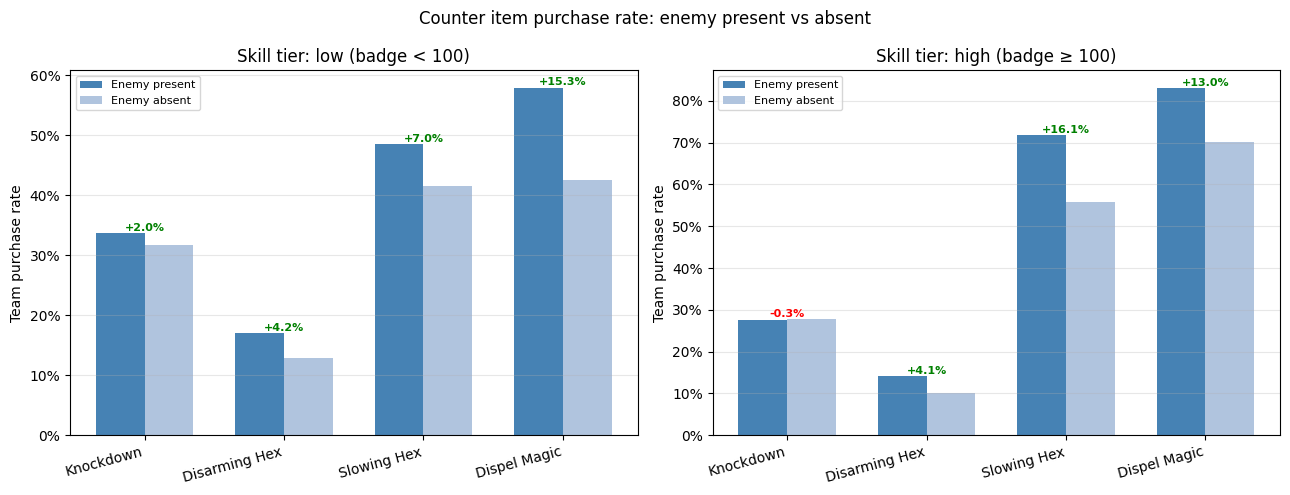

In [213]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
tiers  = ['low', 'high']
items  = list(COUNTER_PAIRS.keys())
x      = np.arange(len(items))
width  = 0.35

for ax, tier in zip(axes, tiers):
    sub = sanity_df[sanity_df['skill_tier'] == tier]
    w   = sub.set_index('item').loc[items, 'bought_w_enemy'].values
    wo  = sub.set_index('item').loc[items, 'bought_wo_enemy'].values

    ax.bar(x - width/2, w,  width, label='Enemy present',  color='steelblue')
    ax.bar(x + width/2, wo, width, label='Enemy absent',   color='lightsteelblue')

    ax.set_title(f'Skill tier: {tier} (badge {"≥" if tier == "high" else "<"} 100)')
    ax.set_xticks(x)
    ax.set_xticklabels(items, rotation=15, ha='right')
    ax.set_ylabel('Team purchase rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    for i, (a, b) in enumerate(zip(w, wo)):
        delta = a - b
        color = 'green' if delta > 0 else 'red'
        ax.annotate(f'{delta:+.1%}', xy=(i, max(a, b) + 0.004),
                    ha='center', fontsize=8, color=color, fontweight='bold')

fig.suptitle('Counter item purchase rate: enemy present vs absent', fontsize=12)
plt.tight_layout()
plt.show()


,item,n_with,n_without,rate_w_dyn,rate_wo_dyn,delta
56,Healbane,428,1572,0.708,0.632,0.076
32,Echo Shard,428,1572,0.371,0.304,0.067
88,Mystic Shot,428,1572,0.367,0.303,0.064
148,Vortex Web,428,1572,0.238,0.181,0.058
91,Opening Rounds,428,1572,0.334,0.280,0.054
53,Guardian Ward,428,1572,0.182,0.132,0.051
43,Extra Spirit,428,1572,0.203,0.156,0.047
39,Extended Magazine,428,1572,0.096,0.051,0.045
2,Arcane Surge,428,1572,0.460,0.417,0.043
44,Extra Stamina,428,1572,0.257,0.214,0.043


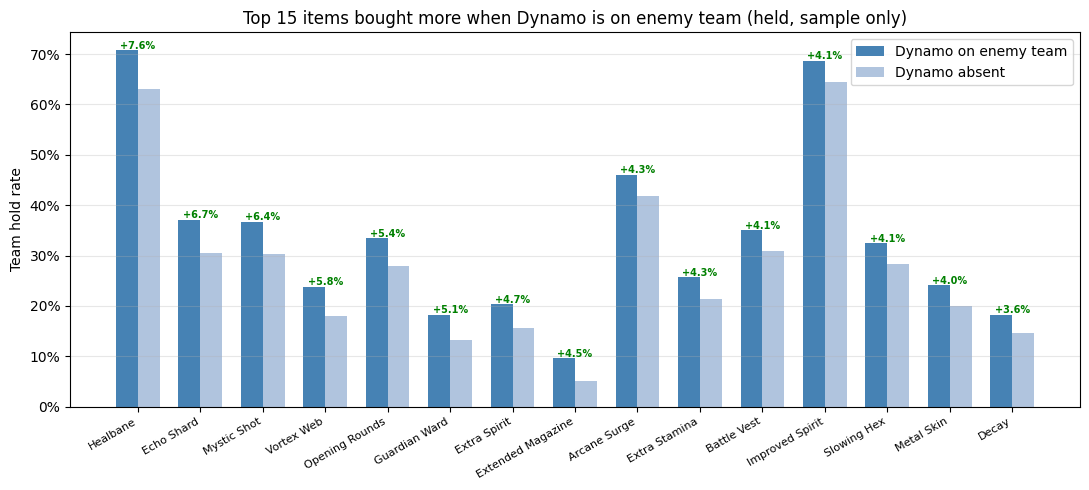

In [214]:
# Which items are actually bought more when Dynamo is on the enemy team?
# Uses item_presence (held upgrades) joined with enemy_has_Dynamo from model_df

dynamo_flag = model_df[['match_id', 'team', 'enemy_has_Dynamo']]
item_vs_dynamo = item_presence.merge(dynamo_flag, on=['match_id', 'team'])

item_cols = [c for c in item_presence.columns if c not in ('match_id', 'team', 'won')]

rows = []
for col in item_cols:
    with_dyn    = item_vs_dynamo[item_vs_dynamo['enemy_has_Dynamo'] == 1][col]
    without_dyn = item_vs_dynamo[item_vs_dynamo['enemy_has_Dynamo'] == 0][col]
    rows.append({
        'item':         col,
        'n_with':       len(with_dyn),
        'n_without':    len(without_dyn),
        'rate_w_dyn':   with_dyn.mean(),
        'rate_wo_dyn':  without_dyn.mean(),
    })

dynamo_df = pd.DataFrame(rows)
dynamo_df['delta'] = dynamo_df['rate_w_dyn'] - dynamo_df['rate_wo_dyn']
dynamo_df = dynamo_df.sort_values('delta', ascending=False)

display(dynamo_df.head(20).round(3))

# Bar chart: top 15 items by delta
top = dynamo_df.head(15)
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(top))
w = 0.35
ax.bar(x - w/2, top['rate_w_dyn'],  w, label='Dynamo on enemy team', color='steelblue')
ax.bar(x + w/2, top['rate_wo_dyn'], w, label='Dynamo absent',        color='lightsteelblue')
for i, (_, row) in enumerate(top.iterrows()):
    ax.annotate(f"{row['delta']:+.1%}", xy=(i, max(row['rate_w_dyn'], row['rate_wo_dyn']) + 0.003),
                ha='center', fontsize=7, color='green', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top['item'], rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Team hold rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_title('Top 15 items bought more when Dynamo is on enemy team (held, sample only)')
plt.tight_layout()
plt.show()


,item,target_hero,skill_tier,n_bought,n_skipped,wr_bought,wr_skipped,wr_delta
0,Knockdown,Dynamo,high,13,38,0.231,0.447,-0.216
1,Knockdown,Dynamo,low,123,254,0.447,0.449,-0.002
2,Disarming Hex,Haze,high,8,48,0.625,0.521,0.104
3,Disarming Hex,Haze,low,79,420,0.380,0.452,-0.072
4,Slowing Hex,Mina,high,19,13,0.526,0.538,-0.012
5,Slowing Hex,Mina,low,134,301,0.552,0.555,-0.003
6,Dispel Magic,Infernus,high,49,10,0.429,0.400,0.029
7,Dispel Magic,Infernus,low,240,195,0.475,0.390,0.085


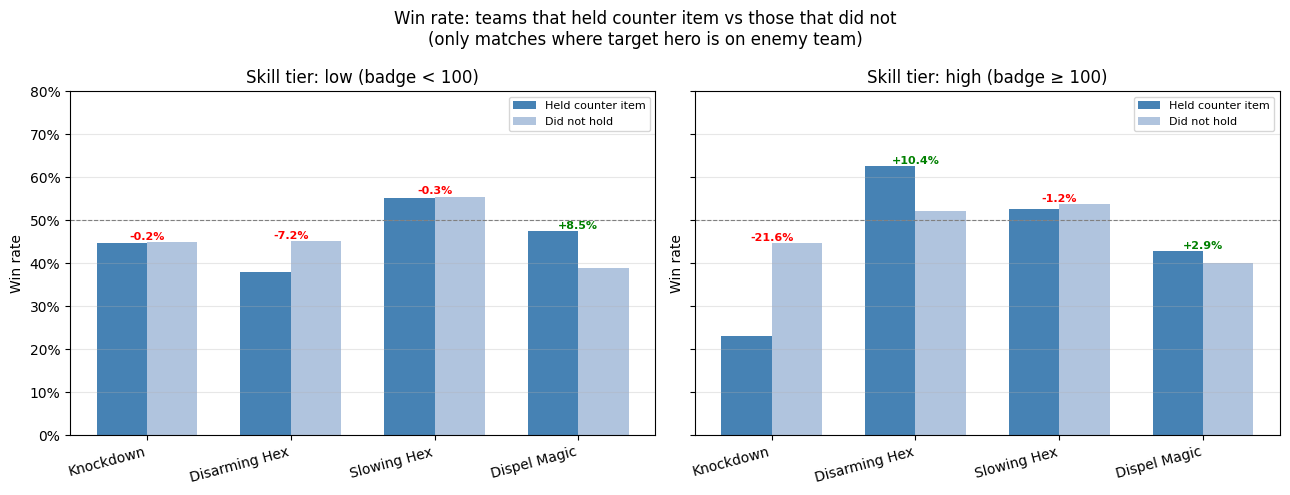

In [215]:
# Win rate comparison for each counter pair
# Only looks at matches where the enemy hero IS present.
# Splits on held_ (item in final build) since a sold item shouldn't get credit for the win.

wr_rows = []
for item, (hero, _) in COUNTER_PAIRS.items():
    enemy_col = f'enemy_has_{hero}'
    held_col  = f'held_{item}'
    if enemy_col not in model_df.columns or held_col not in model_df.columns:
        continue
    for tier, grp in model_df.groupby('skill_tier'):
        facing = grp[grp[enemy_col] == 1]
        bought_item = facing[facing[held_col] == 1]['won']
        skipped     = facing[facing[held_col] == 0]['won']
        wr_rows.append({
            'item':          item,
            'target_hero':   hero,
            'skill_tier':    tier,
            'n_bought':      len(bought_item),
            'n_skipped':     len(skipped),
            'wr_bought':     bought_item.mean().round(3),
            'wr_skipped':    skipped.mean().round(3),
        })

winrate_df = pd.DataFrame(wr_rows)
winrate_df['wr_delta'] = (winrate_df['wr_bought'] - winrate_df['wr_skipped']).round(3)
display(winrate_df)

# Grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
items  = list(COUNTER_PAIRS.keys())
x      = np.arange(len(items))
width  = 0.35

for ax, tier in zip(axes, ['low', 'high']):
    sub      = winrate_df[winrate_df['skill_tier'] == tier].set_index('item').loc[items]
    ax.bar(x - width/2, sub['wr_bought'],  width, label='Held counter item', color='steelblue')
    ax.bar(x + width/2, sub['wr_skipped'], width, label='Did not hold',      color='lightsteelblue')
    for i, (_, row) in enumerate(sub.iterrows()):
        delta = row['wr_delta']
        color = 'green' if delta > 0 else 'red'
        ax.annotate(f'{delta:+.1%}', xy=(i, max(row['wr_bought'], row['wr_skipped']) + 0.005),
                    ha='center', fontsize=8, color=color, fontweight='bold')
    ax.set_title(f'Skill tier: {tier} (badge {"≥" if tier == "high" else "<"} 100)')
    ax.set_xticks(x)
    ax.set_xticklabels(items, rotation=15, ha='right')
    ax.set_ylabel('Win rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_ylim(0, 0.8)
    ax.axhline(0.5, color='grey', linewidth=0.8, linestyle='--')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Win rate: teams that held counter item vs those that did not\n(only matches where target hero is on enemy team)', fontsize=12)
plt.tight_layout()
plt.show()


,item,n_held,n_not_held,wr_held,wr_not,wr_delta
48,Frenzy,31,397,0.677,0.423,0.254
103,Restorative Locket,33,395,0.606,0.428,0.178
29,Divine Barrier,85,343,0.576,0.408,0.168
4,Armor Piercing Rounds,20,408,0.600,0.434,0.166
117,Spirit Burn,214,214,0.523,0.360,0.163
111,Silencer,91,337,0.549,0.412,0.137
33,Enchanter's Emblem,291,137,0.485,0.350,0.135
86,Mystic Reverb,175,253,0.520,0.387,0.133
72,Leech,239,189,0.498,0.370,0.128
21,Crippling Headshot,82,346,0.537,0.419,0.118


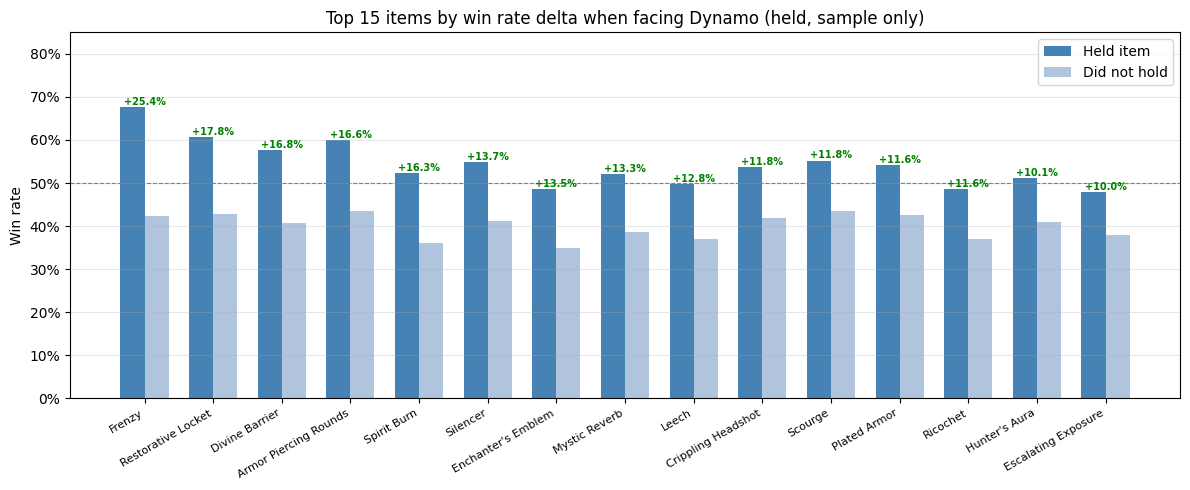

In [216]:
# Dynamo deep dive: which held items correlate with winning when facing Dynamo?
# item_vs_dynamo already carries 'won' from item_presence — no extra merge needed.

facing_dynamo = item_vs_dynamo[item_vs_dynamo['enemy_has_Dynamo'] == 1].copy()

dyn_wr_rows = []
for col in item_cols:
    held     = facing_dynamo[facing_dynamo[col] == 1]['won']
    not_held = facing_dynamo[facing_dynamo[col] == 0]['won']
    if len(held) < 10:
        continue
    dyn_wr_rows.append({
        'item':       col,
        'n_held':     len(held),
        'n_not_held': len(not_held),
        'wr_held':    held.mean().round(3),
        'wr_not':     not_held.mean().round(3),
    })

dyn_wr_df = pd.DataFrame(dyn_wr_rows)
dyn_wr_df['wr_delta'] = (dyn_wr_df['wr_held'] - dyn_wr_df['wr_not']).round(3)
dyn_wr_df = dyn_wr_df.sort_values('wr_delta', ascending=False)

display(dyn_wr_df.head(20))

top = dyn_wr_df.head(15)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(top))
w = 0.35
ax.bar(x - w/2, top['wr_held'], w, label='Held item',     color='steelblue')
ax.bar(x + w/2, top['wr_not'],  w, label='Did not hold', color='lightsteelblue')
for i, (_, row) in enumerate(top.iterrows()):
    color = 'green' if row['wr_delta'] > 0 else 'red'
    ax.annotate(f"{row['wr_delta']:+.1%}", xy=(i, max(row['wr_held'], row['wr_not']) + 0.005),
                ha='center', fontsize=7, color=color, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top['item'], rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Win rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 0.85)
ax.axhline(0.5, color='grey', linewidth=0.8, linestyle='--')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_title('Top 15 items by win rate delta when facing Dynamo (held, sample only)')
plt.tight_layout()
plt.show()


## Target item purchase rates over time

**Note:** The sample spans ~2 hours on a single day, so there are too few distinct time-of-day buckets for a meaningful calendar-time axis. Instead matches are sorted by `start_time` and a rolling window smooths over match sequence — this shows whether purchase behavior drifted across the session. Swap to weekly bins once working with the full dataset.

In [217]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Exact IDs confirmed from public_items.parquet
TARGET_ITEMS = {
    'Knockdown':     np.uint32(1254091416),
    'Disarming Hex': np.uint32(2061878743),
    'Silence Wave':  np.uint32(619484391),
    'Slowing Hex':   np.uint32(1813726886),
    'Dispel Magic':  np.uint32(3731635960),
}

# Match order (sorted chronologically)
match_order = (
    players_df[['match_id', 'start_time']]
    .drop_duplicates()
    .sort_values('start_time')
    .reset_index(drop=True)
    .reset_index()          # index becomes match sequence number
    .rename(columns={'index': 'match_seq'})
)

# Filter items_df to only the target items, compute per-match rates
target_df = items_df[items_df['item_id'].isin(TARGET_ITEMS.values())].copy()

rate_rows = []
for name, iid in TARGET_ITEMS.items():
    for mid in match_order['match_id']:
        sub = target_df[(target_df['match_id'] == mid) & (target_df['item_id'] == iid)]
        rate_rows.append({
            'match_id':  mid,
            'item':      name,
            'held_rate': sub['held'].sum() / 12,
            'any_rate':  len(sub) / 12,
        })

rates_df = (
    pd.DataFrame(rate_rows)
    .merge(match_order[['match_id', 'match_seq']], on='match_id')
    .sort_values(['item', 'match_seq'])
)
display(rates_df.head(10))

,match_id,item,held_rate,any_rate,match_seq
1000,72213176,Disarming Hex,0.083333,0.083333,0
1001,72213184,Disarming Hex,0.000000,0.000000,1
1002,72213187,Disarming Hex,0.166667,0.166667,2
1003,72213189,Disarming Hex,0.083333,0.083333,3
1004,72213204,Disarming Hex,0.083333,0.083333,4
1005,72213205,Disarming Hex,0.083333,0.083333,5
1006,72213207,Disarming Hex,0.000000,0.000000,6
1007,72213208,Disarming Hex,0.000000,0.000000,7
1008,72213210,Disarming Hex,0.000000,0.000000,8
1009,72213220,Disarming Hex,0.083333,0.083333,9


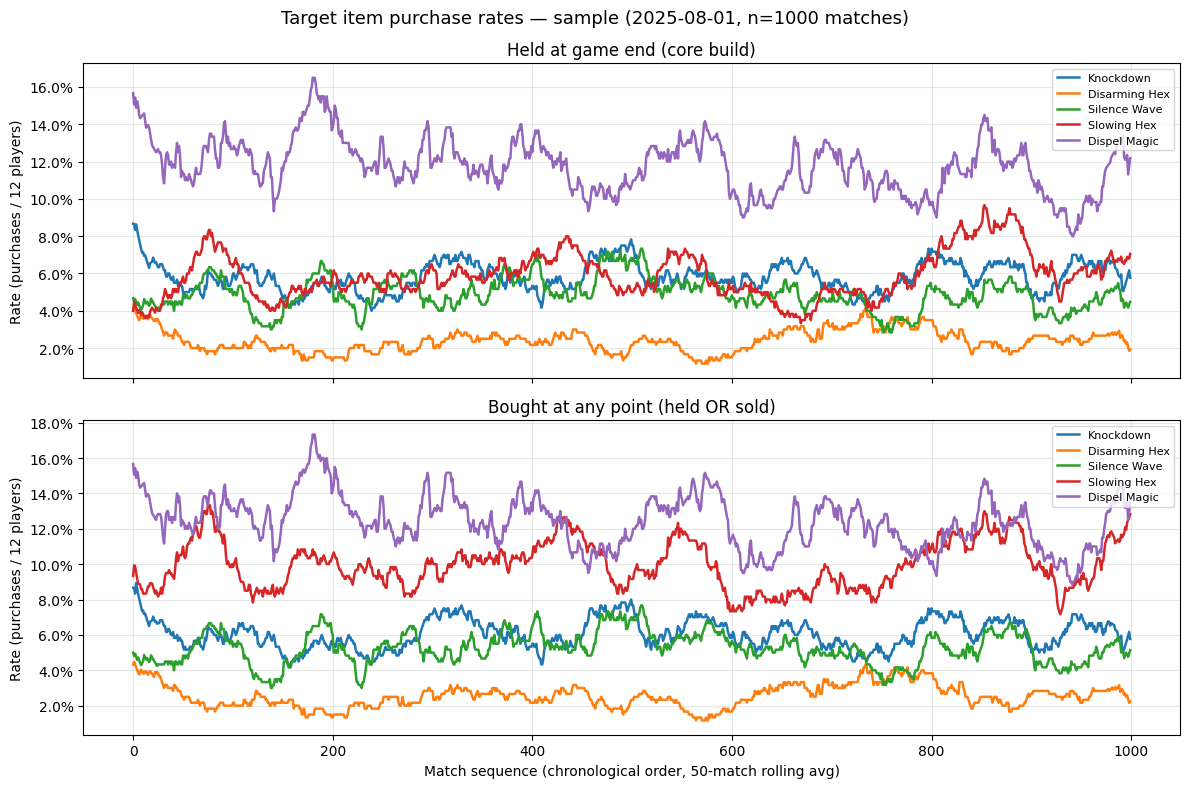

In [218]:
WINDOW = 50  # rolling window in matches; increase to smooth more

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
plot_specs = [
    ('held_rate', 'Held at game end (core build)'),
    ('any_rate',  'Bought at any point (held OR sold)'),
]

for ax, (col, title) in zip(axes, plot_specs):
    for name in TARGET_ITEMS:
        sub = rates_df[rates_df['item'] == name].sort_values('match_seq')
        smoothed = sub[col].rolling(WINDOW, center=True, min_periods=10).mean()
        ax.plot(sub['match_seq'], smoothed, label=name, linewidth=1.8)
    ax.set_ylabel('Rate (purchases / 12 players)')
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

axes[1].set_xlabel(f'Match sequence (chronological order, {WINDOW}-match rolling avg)')
fig.suptitle('Target item purchase rates — sample (2025-08-01, n=1000 matches)', fontsize=13)
plt.tight_layout()
plt.show()